In [1]:
from libra_toolbox.neutron_detection.activation_foils import compass
from libra_toolbox.neutron_detection.activation_foils.calibration import ba133, cs137, co60, na22, mn54
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# read in background spectra

background_measurements = compass.Measurement.from_h5('compass_test_data/background_measurement/background_measurements.h5')

# read in calibration coefficients from json
import json
with open('compass_test_data/background_measurement/calibration_coefficients.json', 'r') as f:
    calibration_coefficients = json.load(f)
print(calibration_coefficients)

{'HPGe': {'0': [1.0198403099123785, 2.689961639523998]}, 'NaI': {'4': [0.7959901704589225, -38.917607406086006], '5': [1.0622115094394577, -30.576666718985596]}}


In [6]:
for measurement in background_measurements:
    for det_type in calibration_coefficients:
        if det_type in measurement.name:
            for detector in measurement.detectors:
                coeffs = calibration_coefficients[det_type][str(detector.channel_nb)]
                detector._calibrated_bin_edges = np.polyval(coeffs, detector._bin_edges)
            
                

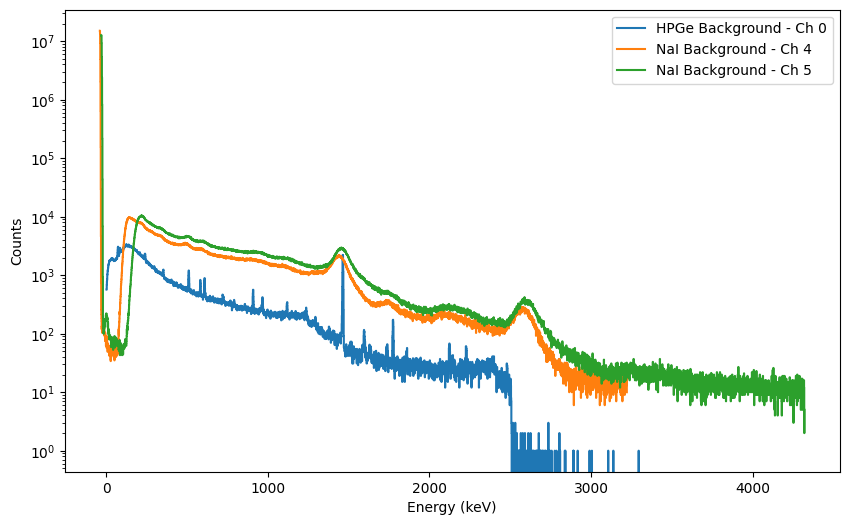

In [11]:
fig, ax = plt.subplots(figsize=(10,6))
for measurement in background_measurements:
    for detector in measurement.detectors:
        ax.step(detector._calibrated_bin_edges[:-1], detector._spectrum, where='post', label=f'{measurement.name} - Ch {detector.channel_nb}')
        ax.set_yscale('log')
        ax.set_xlabel('Energy (keV)')
        ax.set_ylabel('Counts')
        ax.legend()

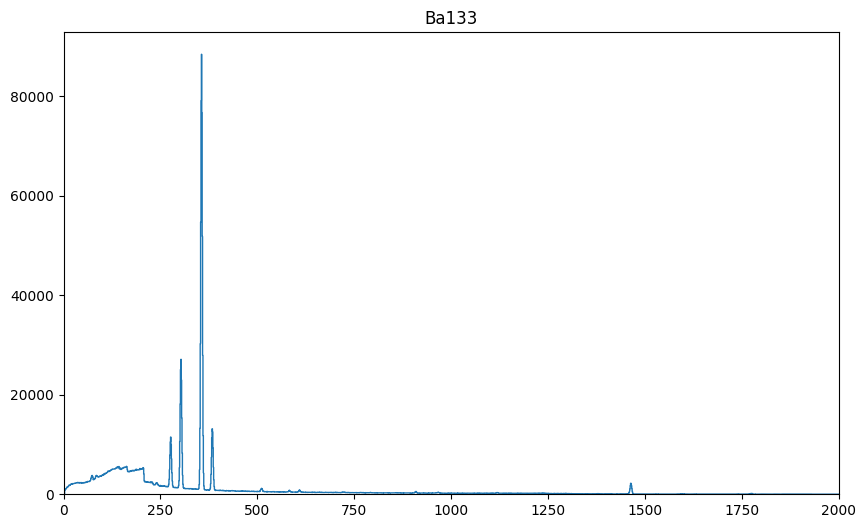

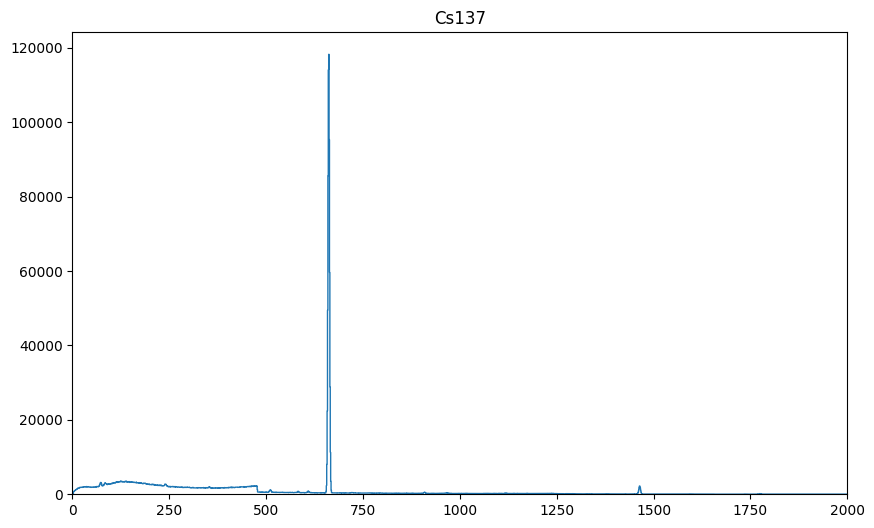

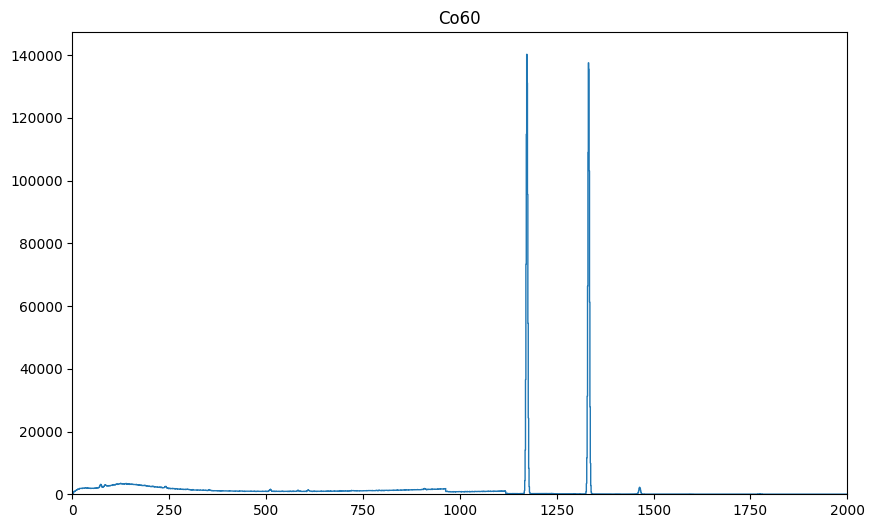

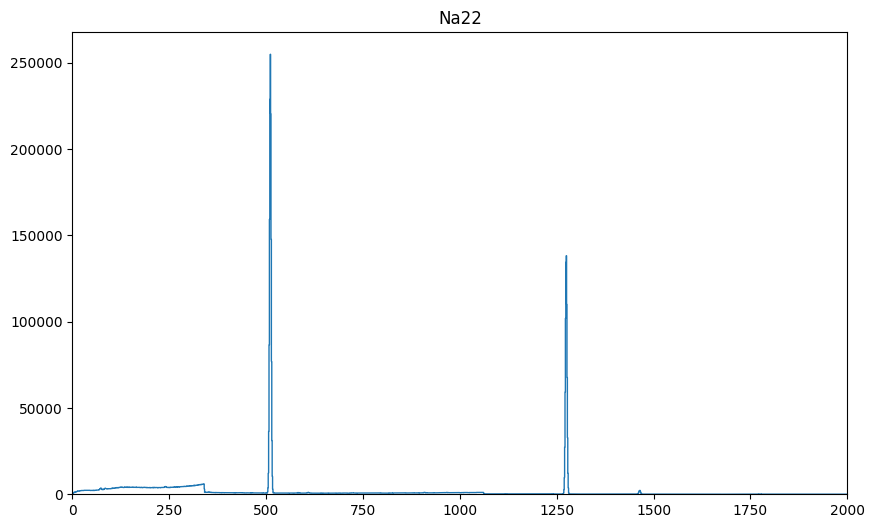

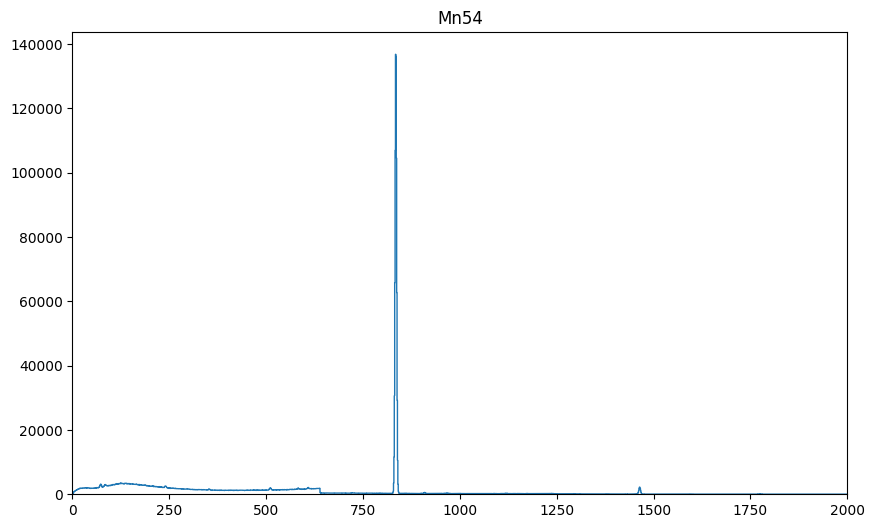

In [29]:
# HPGe spectra simulator
nb_events_measured = 1e6
for nuclide in [ba133, cs137, co60, na22, mn54]:
    fig, ax = plt.subplots(figsize=(10,6))
    nuclide_events = np.zeros((0,))
    for energy, intensity in zip(nuclide.energy, nuclide.intensity):
        compton_fraction = 0.3  # ~30% of events go to Compton scattering
        # Full energy peak
        nuclide_events = np.append(nuclide_events, np.random.normal(
            loc=energy, scale=2, size=int(nb_events_measured * intensity * (1 - compton_fraction))
        ))
        
        # Compton edge
        compton_edge = energy * (1 - 1 / (1 + (2 * energy / 511)))
        compton_events = int(nb_events_measured * intensity * compton_fraction)
        
        # Generate Compton events below the edge with a smooth falloff
        # Using exponential distribution peaked near the edge
        compton_samples = np.random.exponential(
            scale=compton_edge/3, 
            size=compton_events
        )
        # Shift to be centered below the edge
        compton_samples = compton_edge - np.abs(compton_samples)
        compton_samples = compton_samples[compton_samples > 0]  # Remove negative energies
        nuclide_events = np.append(nuclide_events, compton_samples)
    nuclide_hist, bins = np.histogram(nuclide_events, bins=background_measurements[0].detectors[0]._calibrated_bin_edges)
    background_hist = background_measurements[0].detectors[0]._spectrum
    overall_hist = nuclide_hist + background_hist
    ax.stairs(overall_hist, bins, label=nuclide.name)
    ax.set_yscale('linear')
    ax.set_xlim(0, 2000)
    ax.set_title(nuclide.name)

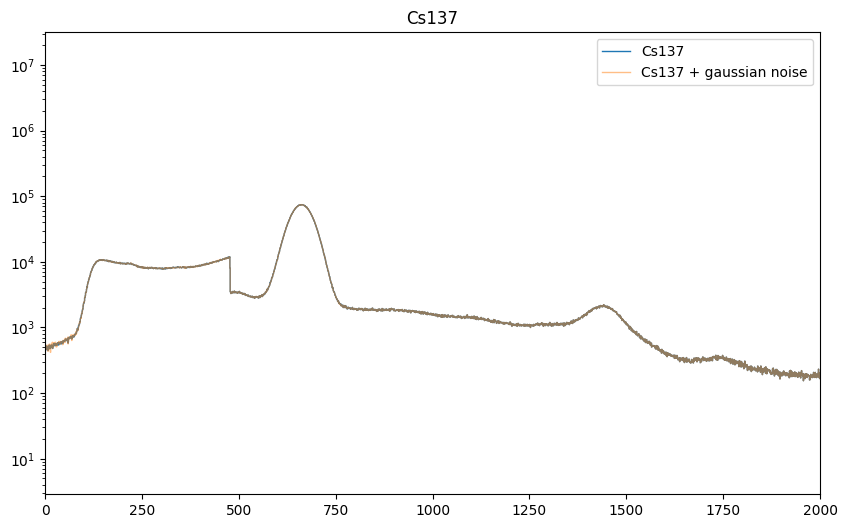

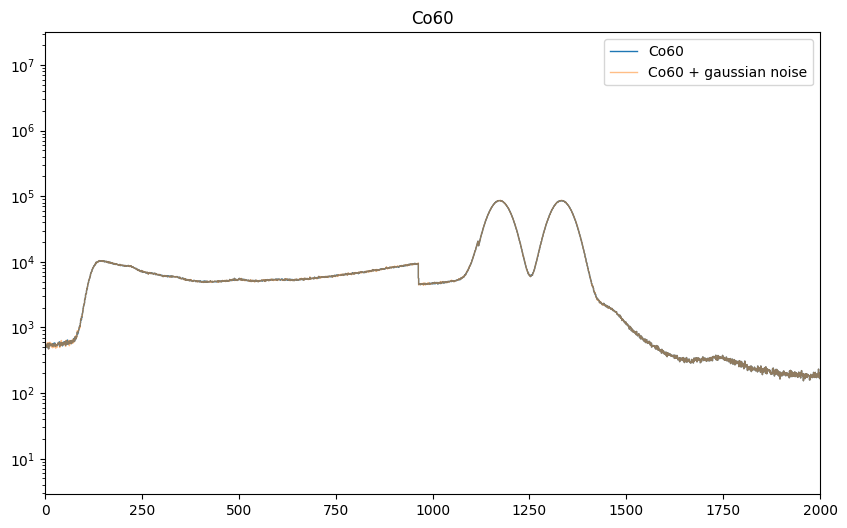

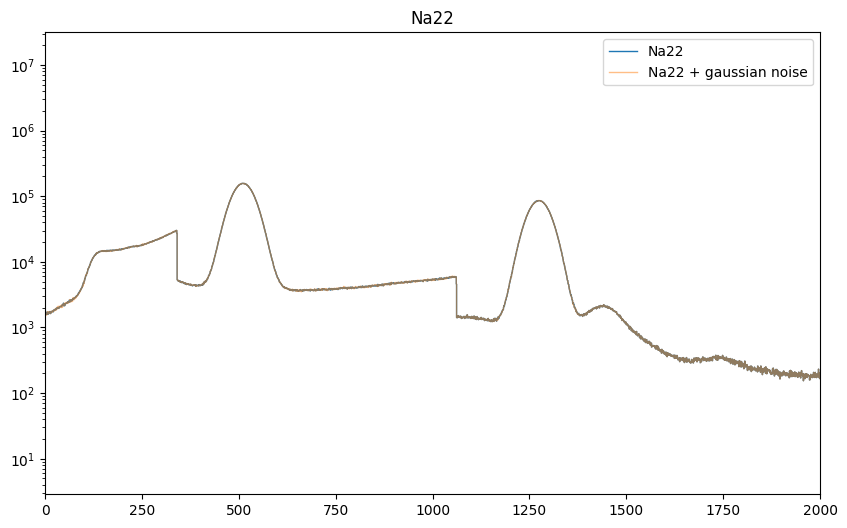

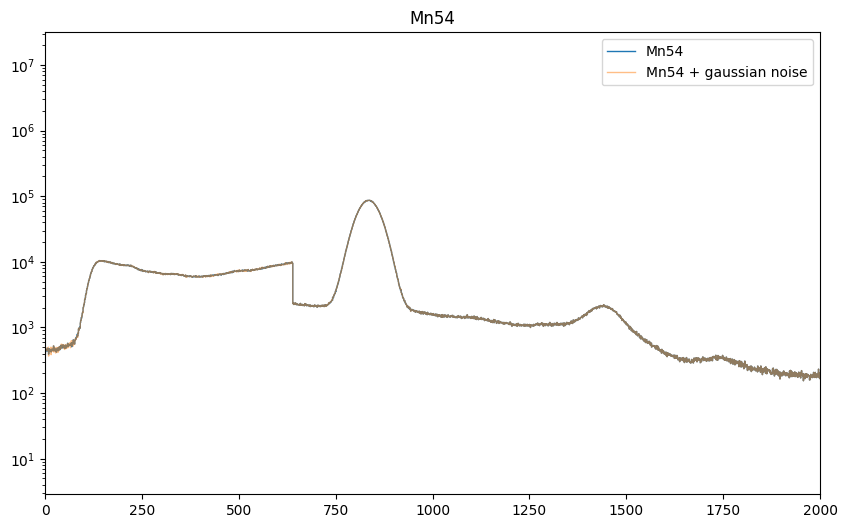

In [ ]:
# NaI spectra simulator
nb_events_measured = 1e7
for nuclide in [cs137, co60, na22, mn54]:
    fig, ax = plt.subplots(figsize=(10,6))
    nuclide_events = np.zeros((0,))
    for energy, intensity in zip(nuclide.energy, nuclide.intensity):
        compton_fraction = 0.2  # ~20% of events go to Compton scattering
        # Full energy peak
        nuclide_events = np.append(nuclide_events, np.random.normal(
            loc=energy, scale=30, size=int(nb_events_measured * intensity * (1 - compton_fraction))
        ))
        
        # Compton edge
        compton_edge = energy * (1 - 1 / (1 + (2 * energy / 511)))
        compton_events = int(nb_events_measured * intensity * compton_fraction)
        
        # Generate Compton events below the edge with a smooth falloff
        # Using exponential distribution peaked near the edge
        compton_samples = np.random.exponential(
            scale=compton_edge/3, 
            size=compton_events
        )
        # Shift to be centered below the edge
        compton_samples = compton_edge - np.abs(compton_samples)
        compton_samples = compton_samples[compton_samples > 0]  # Remove negative energies
        nuclide_events = np.append(nuclide_events, compton_samples)
    nuclide_hist, bins = np.histogram(nuclide_events, bins=background_measurements[1].detectors[0]._calibrated_bin_edges)

    noise_level = 1.0  # 5% relative noise
    gaussian_noise = np.random.normal(0, noise_level * np.sqrt(nuclide_hist), size=nuclide_hist.shape)

    background_hist = background_measurements[1].detectors[0]._spectrum
    overall_hist_no_noise = nuclide_hist + background_hist
    ax.stairs(overall_hist_no_noise, bins, label=nuclide.name)
    overall_hist = nuclide_hist + background_hist + gaussian_noise

    ax.stairs(overall_hist, bins, label=nuclide.name + ' + gaussian noise', alpha=0.5)

    from scipy.ndimage import gaussian_filter1d

    # Energy-dependent broadening based on detector resolution
    # For NaI: FWHM ≈ 7-8% at 662 keV, improves with √E
    bin_centers = (bins[:-1] + bins[1:]) / 2
    fwhm_percent = 7.0  # FWHM as % at 662 keV
    fwhm_energy = (fwhm_percent / 100) * bin_centers * np.sqrt(662 / bin_centers)
    sigma_energy = fwhm_energy / 2.355  # Convert FWHM to sigma
    bin_width = np.mean(np.diff(bins))
    sigma_bins = np.mean(sigma_energy / bin_width)  # Average sigma in bins

    overall_hist_broadened = gaussian_filter1d(overall_hist_no_noise, sigma=sigma_bins)
    ax.stairs(overall_hist_broadened, bins, label=nuclide.name + ' + broadening')
    ax.set_yscale('log')
    ax.set_xlim(0, 2000)
    ax.set_title(nuclide.name)
    ax.legend()